In [2]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

from src.utils import load_config, set_seed
from src.explainability.shap_utils import (
    build_tree_explainer, get_shap_values_for_positive_class,
    sample_for_shap, pick_example_by_class
)

cfg = load_config()
set_seed(cfg["project"]["random_state"])
seed = cfg["project"]["random_state"]

processed_dir = cfg["paths"]["processed_dir"]
models_dir = cfg["paths"]["models_dir"]
figures_dir = cfg["paths"]["figures_dir"]

X_test_selected = pd.read_parquet(os.path.join(processed_dir, "X_test_selected.parquet"))
y_test = pd.read_parquet(os.path.join(processed_dir, "y_test.parquet"))["label_binary"]
final_model = joblib.load(os.path.join(models_dir, "final_model_random_forest.joblib"))

print("Loaded. Test set shape:", X_test_selected.shape)
print("SHAP version:", shap.__version__)

Loaded. Test set shape: (44616, 20)
SHAP version: 0.51.0


In [3]:
#Cell 2 — build explainer, sample test set, compute SHAP values
explainer = build_tree_explainer(final_model)

# Sample 2000 rows from the test set for global SHAP plots (compute efficiency)
X_shap_sample, y_shap_sample = sample_for_shap(X_test_selected, y_test, n_samples=2000, random_state=seed)

shap_values = get_shap_values_for_positive_class(explainer, X_shap_sample)

print("SHAP values shape:", shap_values.shape)
print("Expected shape: (2000, 20)")

SHAP values shape: (2000, 20)
Expected shape: (2000, 20)


C:\Users\ateeq\AppData\Local\Temp\ipykernel_13496\3499397987.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", show=False)


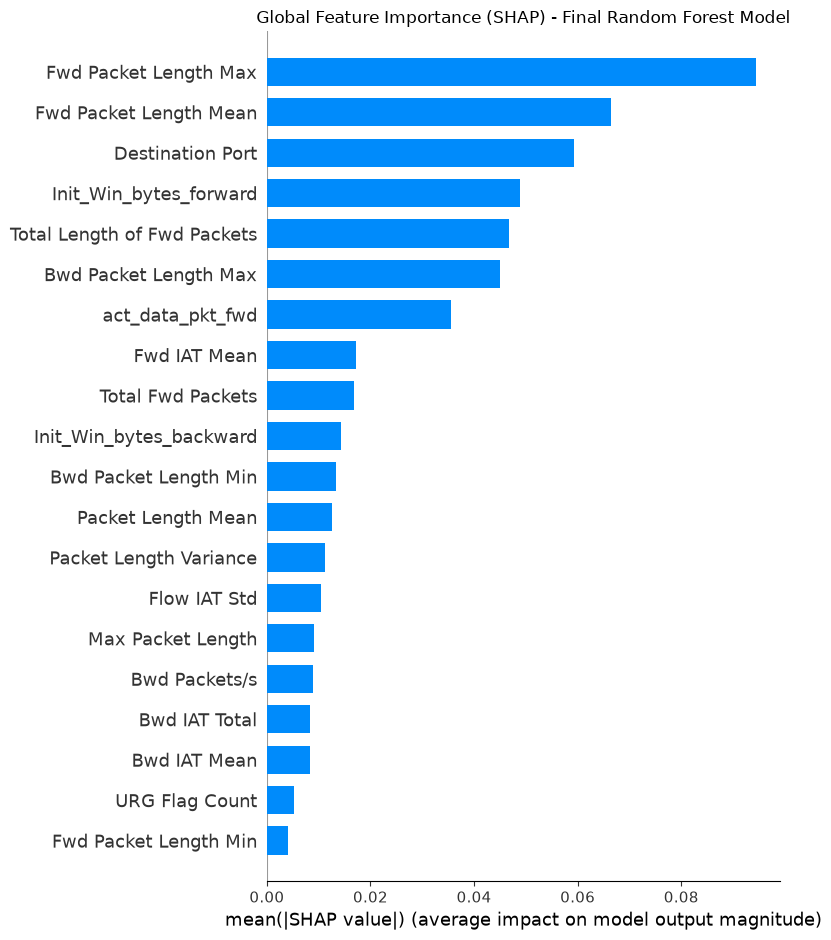

In [4]:
#Cell 3 — Global SHAP bar plot (mean absolute impact per feature)
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP) - Final Random Forest Model")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "shap_bar_global.png"), dpi=150, bbox_inches="tight")
plt.show()

C:\Users\ateeq\AppData\Local\Temp\ipykernel_13496\1879735896.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_sample, plot_type="dot", show=False)


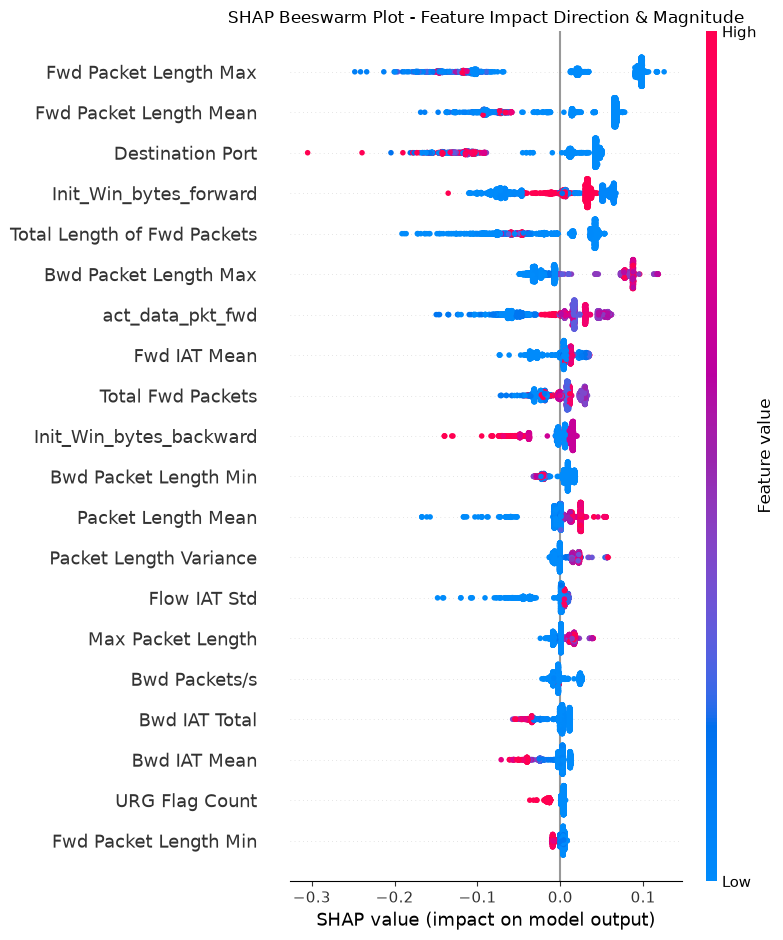

In [5]:
#Cell 4 — SHAP beeswarm plot (shows direction + spread, not just magnitude)
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_sample, plot_type="dot", show=False)
plt.title("SHAP Beeswarm Plot - Feature Impact Direction & Magnitude")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "shap_beeswarm.png"), dpi=150, bbox_inches="tight")
plt.show()

BENIGN example - feature values:
                                  136723
Fwd Packet Length Max          30.000000
Total Length of Fwd Packets    60.000000
Destination Port               53.000000
Init_Win_bytes_forward         -1.000000
act_data_pkt_fwd                1.000000
Bwd Packet Length Max         110.000000
Fwd Packet Length Mean         30.000000
Total Fwd Packets               2.000000
Bwd Packet Length Min         110.000000
Init_Win_bytes_backward        -1.000000
Fwd IAT Mean                   47.000000
Flow IAT Std                   82.273933
Bwd IAT Total                  48.000000
Bwd Packets/s                7017.543860
Max Packet Length             110.000000
Packet Length Mean             62.000000
Bwd IAT Mean                   48.000000
URG Flag Count                  0.000000
Packet Length Variance       1920.000000
Fwd Packet Length Min          30.000000

SHAP values for this sample (positive = pushes toward DDoS, negative = pushes toward BENIGN):
Fwd Packet 

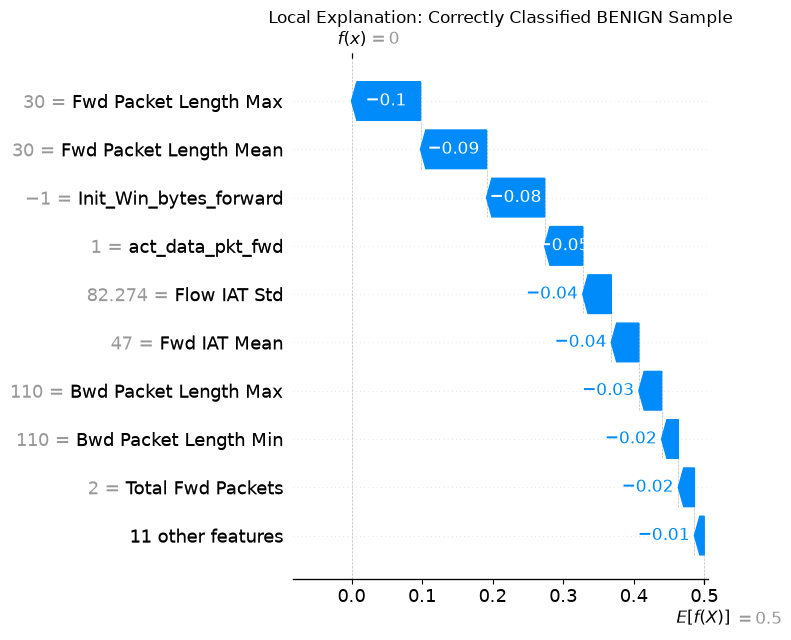

In [9]:
#Cell 5 — Local explanation: one correctly-classified BENIGN sample
import numpy as np

benign_example = pick_example_by_class(X_test_selected, y_test, target_class=0,
                                       model=final_model, random_state=seed)

benign_shap = get_shap_values_for_positive_class(explainer, benign_example)

print("BENIGN example - feature values:")
print(benign_example.T)

print("\nSHAP values for this sample (positive = pushes toward DDoS, negative = pushes toward BENIGN):")
shap_contrib = pd.Series(benign_shap[0], index=X_test_selected.columns).sort_values()
print(shap_contrib)

fig = plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=benign_shap[0],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
        data=benign_example.values[0],
        feature_names=list(X_test_selected.columns)
    ),
    show=False
)
plt.title("Local Explanation: Correctly Classified BENIGN Sample")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "shap_local_benign.png"), dpi=150, bbox_inches="tight")
plt.show()

DDoS example - feature values:
                                  101206
Fwd Packet Length Max              6.000
Total Length of Fwd Packets       24.000
Destination Port                  80.000
Init_Win_bytes_forward           256.000
act_data_pkt_fwd                   3.000
Bwd Packet Length Max              0.000
Fwd Packet Length Mean             6.000
Total Fwd Packets                  4.000
Bwd Packet Length Min              0.000
Init_Win_bytes_backward           -1.000
Fwd IAT Mean                 2852200.000
Flow IAT Std                 4939557.756
Bwd IAT Total                      0.000
Bwd Packets/s                      0.000
Max Packet Length                  6.000
Packet Length Mean                 6.000
Bwd IAT Mean                       0.000
URG Flag Count                     0.000
Packet Length Variance             0.000
Fwd Packet Length Min              6.000

SHAP values for this sample:
Bwd Packet Length Max         -0.006382
Packet Length Variance        -0.00054

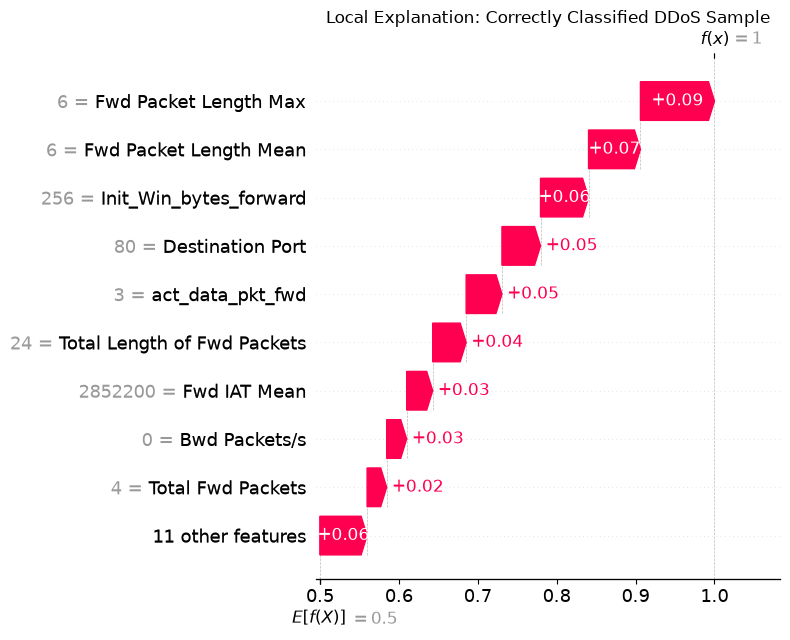

In [10]:
#Cell 6 — Local explanation: one correctly-classified DDoS sample
import numpy as np

ddos_example = pick_example_by_class(X_test_selected, y_test, target_class=1,
                                     model=final_model, random_state=seed)

ddos_shap = get_shap_values_for_positive_class(explainer, ddos_example)

print("DDoS example - feature values:")
print(ddos_example.T)

print("\nSHAP values for this sample:")
shap_contrib_ddos = pd.Series(ddos_shap[0], index=X_test_selected.columns).sort_values()
print(shap_contrib_ddos)

fig = plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=ddos_shap[0],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
        data=ddos_example.values[0],
        feature_names=list(X_test_selected.columns)
    ),
    show=False
)
plt.title("Local Explanation: Correctly Classified DDoS Sample")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "shap_local_ddos.png"), dpi=150, bbox_inches="tight")
plt.show()